# Import Libraries

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch or Load Dataset

In [53]:
data = pd.read_csv("../data/raw/Amazon Sale Report.csv")

C:\Users\altam\AppData\Local\Temp\ipykernel_12628\3426902795.py:1: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/raw/Amazon Sale Report.csv")


# See all Columns

In [54]:
pd.set_option('display.max_columns', None)

# Understanding Dataset

In [55]:
data.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [56]:
#check dataset shape
data.shape

(128975, 24)

In [57]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


# Data Cleaning

In [58]:
# Multiple columns drop
data.drop(columns=['Unnamed: 22', 'fulfilled-by', 'ship-country', 'currency', 'Order ID', 'index'], inplace=True)

In [59]:
# single Column Drop
data.drop('B2B', axis = 1, inplace = True)

In [60]:
# drop NAN vlaues
data.dropna(subset='ship-state', inplace=True)

In [61]:
data.shape

(128942, 17)

# Feature Engineering

In [62]:
# change string data type to datetime data type of 'Date' column
date = pd.to_datetime(data['Date'], format='%m-%d-%y')
data['Date'] = date

In [63]:
data.info()

<class 'pandas.DataFrame'>
Index: 128942 entries, 0 to 128974
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                128942 non-null  datetime64[us]
 1   Status              128942 non-null  str           
 2   Fulfilment          128942 non-null  str           
 3   Sales Channel       128942 non-null  str           
 4   ship-service-level  128942 non-null  str           
 5   Style               128942 non-null  str           
 6   SKU                 128942 non-null  str           
 7   Category            128942 non-null  str           
 8   Size                128942 non-null  str           
 9   ASIN                128942 non-null  str           
 10  Courier Status      122073 non-null  str           
 11  Qty                 128942 non-null  int64         
 12  Amount              121149 non-null  float64       
 13  ship-city           128942 non-null  str     

In [64]:
# check shape
data.shape

(128942, 17)

In [65]:
# making new Columns name with months and years
data['months_num'] = data['Date'].dt.month
data['months_name'] = data['Date'].dt.month_name()
data['years'] = data['Date'].dt.year

# check shape
data.shape

(128942, 20)

In [66]:
data.sample(n=5)

,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,promotion-ids,months_num,months_name,years
48757,2022-04-01,Cancelled,Merchant,Amazon.in,Standard,JNE3797,JNE3797-KR-A-XXL,Western Dress,XXL,B09TH3MNW7,NaN,0,724.76,BENGALURU,KARNATAKA,560100.0,NaN,4,April,2022
100659,2022-06-21,Shipped,Amazon,Amazon.in,Expedited,MEN5009,MEN5009-KR-L,kurta,L,B08YZ24516,Shipped,1,688.00,CHENNAI,TAMIL NADU,600059.0,IN Core Free Shipping 2015/04/08 23-48-5-108,6,June,2022
96804,2022-06-24,Shipped,Amazon,Amazon.in,Expedited,J0011,J0011-LCD-S,Set,S,B08B3YXQJ2,Shipped,1,1610.00,BENGALURU,KARNATAKA,560100.0,NaN,6,June,2022
100156,2022-06-21,Shipped,Amazon,Amazon.in,Standard,SET334,SET334-KR-NP-XL,Set,XL,B09KXV98RR,Shipped,1,0.00,FAIZABAD,UTTAR PRADESH,224001.0,NaN,6,June,2022
69847,2022-05-15,Shipped,Amazon,Amazon.in,Expedited,JNE3468,JNE3468-KR-XXXL,kurta,3XL,B08RP4JJPD,Shipped,1,399.00,MUMBAI,MAHARASHTRA,400043.0,NaN,5,May,2022


In [67]:
# convert data of columns to uppercase and remove leading/trailing whitespace
data['ship-state'] = data['ship-state'].str.upper().str.strip()

In [68]:
# create Dictionary for mapping state names
state_map = {'NEW DELHI': 'DELHI', 'PUNJAB/MOHALI/ZIRAKPUR':'PUNJAB', 'PB':'PUNJAB', 'APO':'ANDHRA PRADESH', 'NL': 'NAGALAND', 'AR': 'ARUNACHAL PRADESH', 'RAJSTHAN':'RAJASTHAN', 'RAJSHTHAN':'RAJASTHAN', 'RJ':'RAJASTHAN', 'ORISSA':'ODISHA', 'PONDICHERRY':'PUDUCHERRY'}

In [69]:
# mapping sates names
data['ship-state'] = data['ship-state'].replace(state_map)

In [70]:
# make upper case and remove trailing/leading whitespace
data['Status'] = data['Status'].str.upper().str.strip()

In [71]:
# create dictionary for mapping status values
status_map = {"SHIPPED - PICKED UP": "SHIPPED/IN TRANSIT","SHIPPED":"SHIPPED/IN TRANSIT", "SHIPPED - OUT FOR DELIVERY":"SHIPPED/IN TRANSIT", "SHIPPED - DELIVERED TO BUYER":"DELIVERED", "CANCELLED":"RETURNED/CANCELLED", "SHIPPED - RETURNING TO SELLER": "RETURNED/CANCELLED", "SHIPPED - RETURNED TO SELLER":"RETURNED/CANCELLED", "SHIPPED - REJECTED BY BUYER":"RETURNED/CANCELLED", "SHIPPED - DAMAGED":"RETURNED/CANCELLED", "PENDING - WAITING FOR PICK UP":"PENDING", "SHIPPED - LOST IN TRANSIT":"LOST", 'SHIPPING':'SHIPPED/IN TRANSIT'}

In [72]:
# Mapping status values
data['Status'] = data['Status'].replace(status_map)

# Visualisation and EDA

### Monthly Sales Analysis
- This analysis focuses on monthly sales trends.

- It helps identify revenue performance across different months.

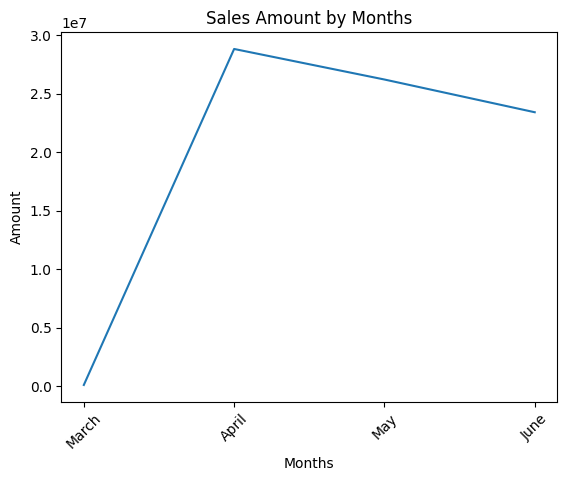

In [88]:
# Bar Graph

monthly_sales = (
    data.groupby(['months_num', 'months_name'])['Amount']
    .sum()
    .reset_index()
    .sort_values('months_num')
    )


# plt.plot(
#     monthly_sales['months_name'],
#     monthly_sales['Amount']
# )

# plt.title('Sales Amount by Months')
# plt.xlabel('Months')
# plt.ylabel('Sales Amount')


# monthly_sales.plot(
#                    x='months_name',
#                    y='Amount',
#                    kind='line',
#                    title='Sales Amount by Months',
#                    xlabel='Months',
#                    ylabel='Sales Amount'
#                 )

# Pure matplotlib plotting
plt.plot(
    monthly_sales['months_name'],
    monthly_sales['Amount']
)

# Titles and labels
plt.title('Sales Amount by Months')
plt.xlabel('Months')
plt.ylabel('Amount')

# Optional: rotate month names for better readability
plt.xticks(rotation=45)

# Show graph
plt.show()



# data.groupby('months')['Amount'].sum().plot(kind='line')
# plt.title('Total sales Amount by Months')
# plt.xlabel('Months')
# plt.ylabel('Sales Amount')

# plt.show()

In [89]:
# data.groupby('months_num')['Amount'].sum()
monthly_sales

,months_num,months_name,Amount
0,3,March,101683.85
1,4,April,28831249.32
2,5,May,26219850.75
3,6,June,23421223.38


### Category-wise Sales Analysis
- This analysis focuses on sales performance across product categories.

- It helps identify high-performing and low-performing categories for business decision-making.

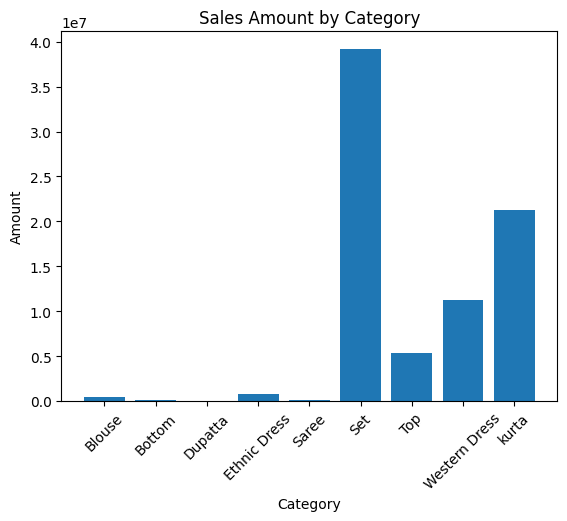

In [75]:
# top to low
# data.groupby('Category')['Amount'].sum().plot(kind='bar',
#                                               title='Sales Amount by Category',
#                                               xlabel='Category',
#                                               ylabel='Sales Amount')

# data.groupby('Category')['Amount'].sum().plot(kind='bar')

# plt.title('Sales Amount by Category')
# plt.xlabel('Category')
# plt.ylabel('Sales Amount')

# plt.show()

category_sales = (
    data.groupby('Category')['Amount']
    .sum()
    .reset_index()
)

plt.bar(
    category_sales['Category'],
    category_sales['Amount']
)

plt.title('Sales Amount by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=45)

plt.show()

In [90]:
# top to low
# data.groupby('Category')['Amount'].sum().sort_values(ascending=False)/
category_sales

,Category,Amount
0,Blouse,458408.18
1,Bottom,150667.98
2,Dupatta,915.00
3,Ethnic Dress,791217.66
4,Saree,123933.76
5,Set,39195176.03
6,Top,5346812.30
7,Western Dress,11215337.69
8,kurta,21291538.70


### State-wise Sales Analysis
- This analysis focuses on sales distribution across different states.

- It helps understand regional sales performance and supports strategic marketing decisions.


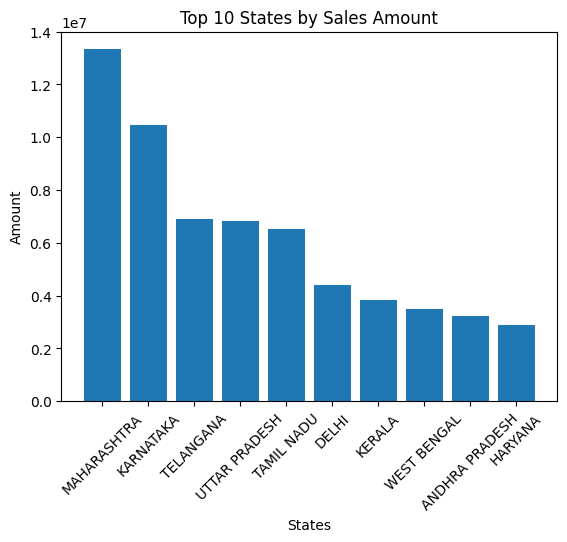

In [83]:
# data.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar',
#                                                                                       title='Top 10 States by Sales Amount',
#                                                                                       xlabel='States',
#                                                                                       ylabel='Sales Amount')

state_sales = (
    data.groupby('ship-state')['Amount']
    .sum()
    .reset_index()
    .sort_values('Amount', ascending=False)
    .head(10)
)

plt.bar(
    state_sales['ship-state'],
    state_sales['Amount']
)

plt.title('Top 10 States by Sales Amount')
plt.xlabel('States')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# data.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)
state_sales

,ship-state,Amount
20,MAHARASHTRA,13335534.14
15,KARNATAKA,10481114.37
31,TELANGANA,6916615.65
33,UTTAR PRADESH,6816642.08
30,TAMIL NADU,6515650.11
8,DELHI,4393522.41
16,KERALA,3830227.58
35,WEST BENGAL,3507880.44
1,ANDHRA PRADESH,3219831.72
11,HARYANA,2882092.99


### Product Style Analysis
- This analysis focuses on the performance of different product styles.

- It helps identify top-performing styles and understand customer preferences.

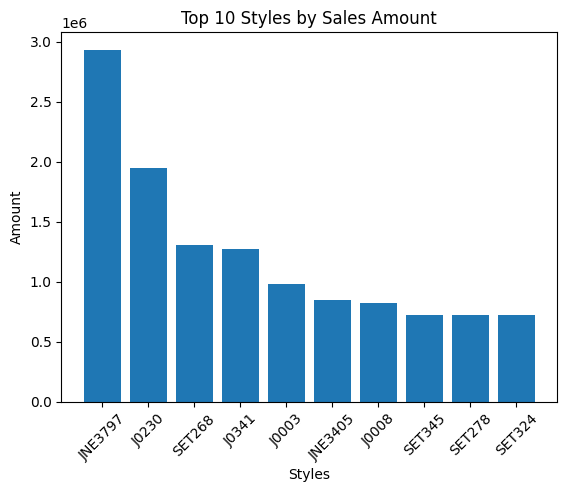

In [92]:
# data.groupby('Style')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar',
#                                                                                  title='Top 10 Styles by Sales Amount',
#                                                                                  xlabel='Styles',
#                                                                                  ylabel='Sales Amount')


style_sales = (
    data.groupby('Style')['Amount']
    .sum()
    .reset_index()
    .sort_values('Amount', ascending=False)
    .head(10)
)

plt.bar(
    style_sales['Style'],
    style_sales['Amount']
)

plt.title('Top 10 Styles by Sales Amount')
plt.xlabel('Styles')
plt.ylabel('Amount')
plt.xticks(rotation=45)

plt.show()

In [ ]:
# data.groupby('Style')['Amount'].sum().sort_values(ascending=False).head(10)
style_sales

,Style,Amount
863,JNE3797,2932747.00
302,J0230,1943836.48
1240,SET268,1303923.56
373,J0341,1275322.87
111,J0003,980665.75
555,JNE3405,846062.36
116,J0008,819169.96
1308,SET345,723402.79
1250,SET278,719791.48
1287,SET324,719489.82


### Order Status Analysis
- This analysis focuses on the distribution of different order statuses.

- It helps evaluate delivery performance, returned/cancelled orders, and operational efficiency.

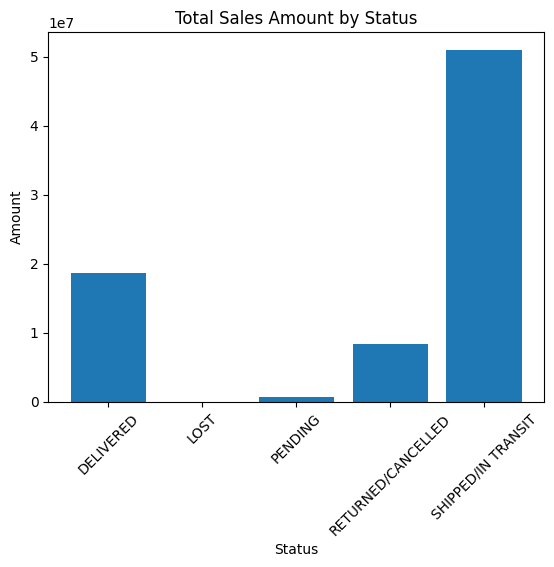

In [96]:
# data.groupby('Status')['Amount'].sum().plot(kind='bar',
#                                             title='Total Sales Amount by Status',
#                                             xlabel='Status',
#                                             ylabel='Sales Amount')

status_sales = (
    data.groupby('Status')['Amount']
    .sum()
    .reset_index()
)

plt.bar(
    status_sales['Status'],
    status_sales['Amount']
)

plt.title('Total Sales Amount by Status')
plt.xlabel('Status')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()

In [97]:
# data.groupby('Status')['Amount'].sum()

status_sales

,Status,Amount
0,DELIVERED,18645779.0
1,LOST,1997.0
2,PENDING,622409.0
3,RETURNED/CANCELLED,8301320.3
4,SHIPPED/IN TRANSIT,51002502.0


# Save New CSV file 

In [64]:
data.to_csv('../data/cleaned/cleaned_amazon_sales_report.csv', index=False)

# Key Insights

- Maharashtra generated the highest sales revenue among all the states.

- The 'Set' category contributed the highest overall Sales.

- Style JNE3797 was the top - performing product style.

- April recorded the highest monthly sales in the dataset.

- A significant portion of revenue was associated with returned/cancelled orders.

- Most order were in the ship/in-transit stage.

# Conclusion

### This Project involved cleaning, transforming, and analyzing e-commerce sales data to identify important business trends and operational patterns. The analysis helped uncover high performing product categories, top-selling states, monthly sales trends, and order status distribution. This project also demonstrated the data cleaning, feature engineering, exploratory data analysis(EDA), and visualisation skills using python libraries.

# Business Recommendations

- The company should investigate the high number of returned and cancelled orders to identify possible operational or customer satisfaction issues.

- Marketing and sales strategies can be expanded in lower-performing states to improve regional revenue distribution.

- Sales performance during May and June should be analyzed further to identify factors behind lower revenue compared to April.

- The company should monitor pending and lost shipment statuses to improve logistics and delivery efficiency.

- Since a small number of product styles dominate sales revenue, the company can explore product diversification strategies to improve sales distribution across styles.